In [1]:
import pandas as pd
import numpy as np

merged = pd.read_parquet('/Users/shreya/Documents/College/Sem 5/ML/Lab/GridSense/data/processed/merged.parquet')
merged_encoded = pd.get_dummies(merged, columns=['location'], drop_first=True)

feature_cols = ['temperature', 'humidity', 'hour', 'day_of_week', 'month', 
                 'is_holiday', 'historical_avg_load'] + \
                [c for c in merged_encoded.columns if c.startswith('location_')]

X = merged_encoded[feature_cols]
y = merged_encoded['demand_gw']

merged_encoded = merged_encoded.sort_values('datetime')
split_idx = int(len(merged_encoded) * 0.85)

train_idx = merged_encoded.index[:split_idx]
test_idx = merged_encoded.index[split_idx:]

X_train, X_test = X.loc[train_idx], X.loc[test_idx]
y_train, y_test = y.loc[train_idx], y.loc[test_idx]

X_test_with_meta = merged.loc[test_idx, ['location', 'datetime']].copy()
X_test_with_meta['actual'] = y_test.values

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train size: 238312, Test size: 42056


In [2]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error

xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

mae = mean_absolute_error(y_test, xgb_preds)
rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
print(f"XGBoost — MAE: {mae:.2f} GW, RMSE: {rmse:.2f} GW")

X_test_with_meta['xgb_predicted'] = xgb_preds
X_test_with_meta['xgb_abs_error'] = (X_test_with_meta['actual'] - X_test_with_meta['xgb_predicted']).abs()
X_test_with_meta['xgb_pct_error'] = (X_test_with_meta['xgb_abs_error'] / X_test_with_meta['actual']) * 100

print(X_test_with_meta.groupby('location')['xgb_pct_error'].mean().sort_values())

XGBoost — MAE: 9.69 GW, RMSE: 14.44 GW
location
Eastern          12.825275
Northern         14.114120
National         15.414219
North-Eastern    15.714856
Western          16.030667
Southern         17.745783
Name: xgb_pct_error, dtype: float64


In [3]:
import joblib
import os

os.makedirs('models', exist_ok=True)
joblib.dump(xgb_model, 'models/xgb_demand_model.joblib')
joblib.dump(feature_cols, 'models/feature_cols.joblib')  # save this too — your FastAPI backend needs to know exact column order later

['models/feature_cols.joblib']

Matplotlib is building the font cache; this may take a moment.


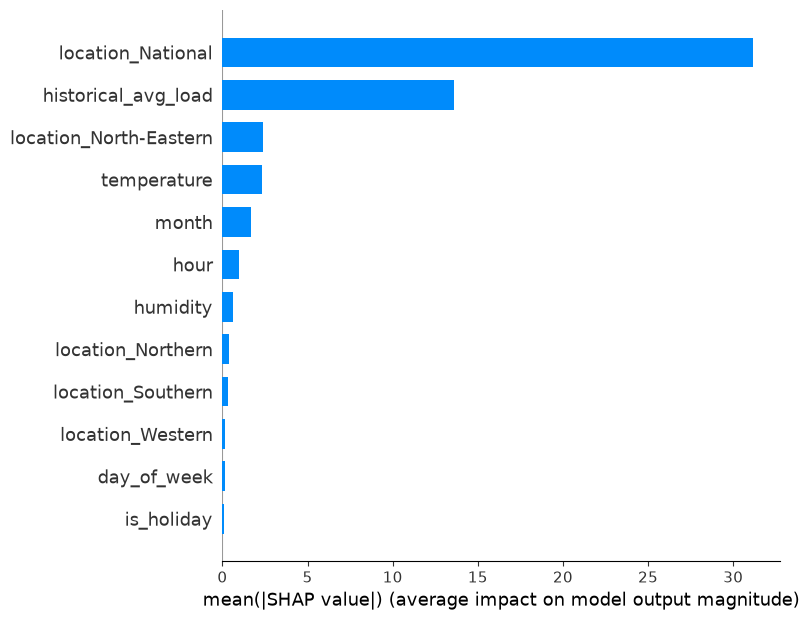

In [4]:
import shap

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# global feature importance — which features matter most overall
shap.summary_plot(shap_values, X_test, plot_type='bar')

In [ ]:
# ## SHAP including location (raw)
# Location dominates due to scale differences across regions — not a useful
# signal for the explanation panel since the user already selected location.
# pick one row to explain, e.g. the first test row
row_idx = 0
row_shap = shap_values[row_idx]

# convert to contribution percentages, matching your API contract shape
feature_contributions = pd.Series(row_shap, index=feature_cols).abs()
feature_contributions_pct = (feature_contributions / feature_contributions.sum() * 100).sort_values(ascending=False)
print(feature_contributions_pct.head(10))

location_National         67.487389
historical_avg_load       11.014778
location_North-Eastern     5.746720
temperature                4.782185
hour                       4.042771
location_Northern          3.024810
location_Southern          1.555829
month                      1.213259
humidity                   0.607932
day_of_week                0.375062
dtype: float32


In [ ]:
## SHAP excluding location (used for /explain endpoint)
# This is the breakdown actually shown to the user — drivers *within* the
# selected location's forecast.
# recompute contribution %, excluding location_* columns from the display
non_location_features = [c for c in feature_cols if not c.startswith('location_')]

row_shap_filtered = pd.Series(shap_values[row_idx], index=feature_cols)[non_location_features].abs()
row_shap_pct = (row_shap_filtered / row_shap_filtered.sum() * 100).sort_values(ascending=False)
print(row_shap_pct)

historical_avg_load    49.664742
temperature            21.562483
hour                   18.228529
month                   5.470487
humidity                2.741115
day_of_week             1.691125
is_holiday              0.641519
dtype: float32


In [8]:
def get_explanation(row_features_df, model, explainer, feature_cols, non_location_features, top_n=5):
    """
    row_features_df: single-row DataFrame with the same columns as X_train,
    in the same order (use feature_cols to enforce this)
    """
    shap_vals = explainer.shap_values(row_features_df[feature_cols])[0]
    contributions = pd.Series(shap_vals, index=feature_cols)[non_location_features].abs()
    contributions_pct = (contributions / contributions.sum() * 100).sort_values(ascending=False)
    return contributions_pct.head(top_n).to_dict()

# test it works on an arbitrary row, not just row_idx=0
test_row = X_test.iloc[[5]]
print(get_explanation(test_row, xgb_model, explainer, feature_cols, non_location_features))

{'historical_avg_load': 37.68682861328125, 'temperature': 23.042724609375, 'hour': 20.452816009521484, 'month': 11.885109901428223, 'humidity': 4.132922172546387}


In [9]:
def get_whatif_prediction(row_features_df, model, feature_cols, changed_feature, delta):
    """
    row_features_df: single-row DataFrame, same columns/order as X_train
    changed_feature: e.g. 'temperature'
    delta: e.g. +4
    """
    modified_row = row_features_df.copy()
    modified_row[changed_feature] = modified_row[changed_feature] + delta
    
    original_pred = model.predict(row_features_df[feature_cols])[0]
    new_pred = model.predict(modified_row[feature_cols])[0]
    
    return {
        'original_demand_gw': float(original_pred),
        'new_demand_gw': float(new_pred),
        'change_gw': float(new_pred - original_pred)
    }

# test it
test_row = X_test.iloc[[5]]
print(get_whatif_prediction(test_row, xgb_model, feature_cols, 'temperature', 4))

{'original_demand_gw': 36.64535903930664, 'new_demand_gw': 39.37813949584961, 'change_gw': 2.7327804565429688}


In [10]:
# build the "typical" baseline per location/hour/day_of_week from training data
typical_stats = (
    merged.loc[train_idx]
    .groupby(['location', 'hour', 'day_of_week'])['demand_gw']
    .agg(['mean', 'std'])
    .reset_index()
)

def flag_anomalies(predictions_df, typical_stats, threshold=2):
    """
    predictions_df: DataFrame with columns location, hour, day_of_week, predicted_demand_gw
    """
    merged_check = predictions_df.merge(typical_stats, on=['location', 'hour', 'day_of_week'], how='left')
    merged_check['z_score'] = (merged_check['predicted_demand_gw'] - merged_check['mean']) / merged_check['std']
    merged_check['is_anomaly'] = merged_check['z_score'].abs() > threshold
    return merged_check[['location', 'hour', 'day_of_week', 'predicted_demand_gw', 'z_score', 'is_anomaly']]

In [11]:
# build a small test set of "predictions" to check against
test_sample = merged.loc[test_idx, ['location', 'hour', 'day_of_week']].copy()
test_sample['predicted_demand_gw'] = xgb_preds  # from your earlier XGBoost predictions

anomaly_results = flag_anomalies(test_sample, typical_stats, threshold=2)
print(f"Anomalies flagged: {anomaly_results['is_anomaly'].sum()} out of {len(anomaly_results)}")
anomaly_results[anomaly_results['is_anomaly']].head(10)

Anomalies flagged: 1098 out of 42056


,location,hour,day_of_week,predicted_demand_gw,z_score,is_anomaly
622,North-Eastern,6,1,2.453905,2.851959,True
653,North-Eastern,11,1,2.604889,2.641162,True
660,North-Eastern,12,1,2.557128,2.336279,True
663,North-Eastern,13,1,2.802664,3.005704,True
673,North-Eastern,14,1,3.467152,4.856057,True
678,North-Eastern,15,1,3.711146,5.396333,True
681,North-Eastern,16,1,3.433812,4.714438,True
689,North-Eastern,17,1,3.018950,2.295321,True
706,North-Eastern,20,1,3.390431,2.685921,True
715,North-Eastern,21,1,3.149173,2.214384,True


In [13]:
test_sample = merged.loc[test_idx, ['datetime', 'location', 'hour', 'day_of_week']].copy()
test_sample['predicted_demand_gw'] = xgb_preds

anomaly_results = flag_anomalies(test_sample, typical_stats, threshold=2)

In [16]:
# 1. redefine the function (make sure this cell actually executes)
def flag_anomalies(predictions_df, typical_stats, threshold=2):
    merged_check = predictions_df.merge(typical_stats, on=['location', 'hour', 'day_of_week'], how='left')
    merged_check['z_score'] = (merged_check['predicted_demand_gw'] - merged_check['mean']) / merged_check['std']
    merged_check['is_anomaly'] = merged_check['z_score'].abs() > threshold
    return merged_check[['datetime', 'location', 'hour', 'day_of_week', 'predicted_demand_gw', 'z_score', 'is_anomaly']]

In [17]:
# 2. rebuild test_sample WITH datetime included
test_sample = merged.loc[test_idx, ['datetime', 'location', 'hour', 'day_of_week']].copy()
test_sample['predicted_demand_gw'] = xgb_preds

print(test_sample.columns.tolist())  # sanity check — should show datetime

['datetime', 'location', 'hour', 'day_of_week', 'predicted_demand_gw']


In [18]:
# 3. now call it
anomaly_results = flag_anomalies(test_sample, typical_stats, threshold=2)
print(anomaly_results.columns.tolist())  # confirm datetime made it through

['datetime', 'location', 'hour', 'day_of_week', 'predicted_demand_gw', 'z_score', 'is_anomaly']


In [19]:
anomalies_only = anomaly_results[anomaly_results['is_anomaly']]
print(anomalies_only[anomalies_only['location']=='North-Eastern']['datetime'].dt.date.value_counts().head(10))
print(anomalies_only['location'].value_counts())

datetime
2023-11-12    21
2024-04-11    19
2023-08-01    18
2023-07-19    16
2023-09-06    16
2023-07-20    15
2023-11-27    15
2023-12-25    14
2024-03-25    14
2024-04-17    14
Name: count, dtype: int64
location
North-Eastern    1019
Northern           56
Eastern            21
Western             2
Name: count, dtype: int64


In [22]:
train_df = merged.loc[train_idx]
test_df = merged.loc[test_idx]

ne_train_mean = train_df[train_df['location']=='North-Eastern']['demand_gw'].mean()
ne_test_mean = test_df[test_df['location']=='North-Eastern']['demand_gw'].mean()
print(f"NE train mean: {ne_train_mean:.2f} GW, NE test mean: {ne_test_mean:.2f} GW")

NE train mean: 1.98 GW, NE test mean: 2.19 GW


In [23]:
avg_std_by_location = typical_stats.groupby('location')['std'].mean().sort_values()
print(avg_std_by_location)

location
North-Eastern     0.312568
Eastern           3.093827
Southern          5.558022
Western           6.724148
Northern          9.554748
National         18.912437
Name: std, dtype: float64


In [24]:
import joblib

joblib.dump(xgb_model, 'models/xgb_demand_model.joblib')
joblib.dump(explainer, 'models/shap_explainer.joblib')
joblib.dump(feature_cols, 'models/feature_cols.joblib')
joblib.dump(non_location_features, 'models/non_location_features.joblib')
typical_stats.to_parquet('/Users/shreya/Documents/College/Sem 5/ML/Lab/GridSense/data/processed/typical_stats.parquet', index=False)